# XGBoost por Cluster — Pre-TEC21 y TEC21
### Predicción de Deserción con SMOTE + Optimización de Umbral + SHAP

Este notebook entrena un modelo **XGBoost** independiente para cada cluster
identificado en el análisis de K-Means. A diferencia del Random Forest previo,
incorpora tres mejoras clave:

1. **SMOTE** (Synthetic Minority Over-sampling Technique) para manejar el desbalance de clases.
2. **Optimización del umbral de decisión** para maximizar F1 en cada cluster.
3. **XGBoost** como algoritmo de Gradient Boosting, que supera sistemáticamente
   a Random Forest en datasets tabulares desbalanceados.

---

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, precision_recall_curve)

SEED     = 42
DATA_DIR = '/sessions/admiring-confident-hopper/mnt/ife-student-dropout-prediction/data/'

FEATURES = ['PNA','is_foreign','estuvo.prepa_tec','first.generation.yes',
            'has_extracurriculars','parents_exatec_enc','total.scholarship.loan','FTE']

FEAT_LABELS = {
    'PNA':                   'PNA',
    'is_foreign':            'Extranjero',
    'estuvo.prepa_tec':      'Prepa Tec',
    'first.generation.yes':  '1ra Generación',
    'has_extracurriculars':  'Extracurriculares',
    'parents_exatec_enc':    'Padres Exatec',
    'total.scholarship.loan':'Beca/Préstamo',
    'FTE':                   'FTE',
}

PAL = ['#16a34a','#22c55e','#3b82f6','#f59e0b','#f97316','#ef4444']

import xgboost, imblearn, shap as shap_lib, sklearn
print(f"XGBoost        : {xgboost.__version__}")
print(f"imbalanced-learn: {imblearn.__version__}")
print(f"SHAP           : {shap_lib.__version__}")
print(f"scikit-learn   : {sklearn.__version__}")

XGBoost        : 3.2.0
imbalanced-learn: 0.14.1
SHAP           : 0.49.1
scikit-learn   : 1.7.2


---
## 1. ¿Por qué XGBoost mejora sobre Random Forest?

### Random Forest vs XGBoost

| Aspecto | Random Forest | XGBoost |
|---|---|---|
| Construcción | Árboles **paralelos e independientes** (Bagging) | Árboles **secuenciales** (Boosting): cada árbol corrige los errores del anterior |
| Enfoque en errores | Todos los ejemplos tienen el mismo peso | Los ejemplos mal clasificados reciben **más peso** en el siguiente árbol |
| Regularización | Solo max_depth / min_samples | L1, L2, `gamma` (penaliza hojas extra) |
| Desbalance | `class_weight='balanced'` pondera internamente | `scale_pos_weight` + SMOTE externo combinado |
| Velocidad | Paralelizable por árbol | Más lento por ser secuencial, pero converge mejor |

La clave del boosting: si en el paso t el modelo falla con los estudiantes de `C4_extranjeros`
que sí desertaron, el árbol t+1 se entrena poniendo **mayor atención** precisamente en esos casos.
Esto es especialmente útil con clases minoritarias pequeñas como la deserción.

---

## 2. ¿Qué es SMOTE y por qué ayuda?

**SMOTE** (Synthetic Minority Over-sampling Technique) crea ejemplos sintéticos de la clase
minoritaria (desertores) interpolando entre ejemplos reales existentes.

```
Estudiante A (desertor): PNA=60, beca=0, extracurr=0, FTE=1.0
Estudiante B (desertor): PNA=65, beca=1, extracurr=0, FTE=0.8
SMOTE genera:            PNA=62, beca=0.4, extracurr=0, FTE=0.9  ← punto interpolado
```

**¿Por qué no basta con `class_weight`?**
El peso de clase dice al modelo "estos errores cuestan más", pero el modelo sigue viendo
pocos ejemplos reales de desertores y puede no aprender sus patrones bien.
SMOTE literalmente le muestra más variantes del problema.

**Importante**: SMOTE se aplica **solo en entrenamiento**, nunca en el test set.
Si se aplica en test, el modelo aprende patrones sintéticos y las métricas se inflan artificialmente.

---

## 3. ¿Qué es la optimización del umbral?

Por defecto, todos los clasificadores usan umbral = 0.5: si la probabilidad predicha
de deserción supera 0.5, se clasifica como desertor.

**Problema**: Con 5% de tasa de deserción, el modelo aprende que predecir siempre
"no deserta" da 95% de accuracy. El umbral de 0.5 sesga hacia la clase mayoritaria.

**Solución**: Buscar el umbral t* que **maximiza F1** en el set de validación:

```
Para cada t en [0.01, 0.99]:
    y_pred = (probabilidades > t).astype(int)
    f1 = f1_score(y_val, y_pred)
t* = argmax(f1)
```

Esto permite balancear precision y recall según las necesidades:
- Si t* < 0.5 → el modelo necesita ser más "valiente" para predecir deserción
- Si t* > 0.5 → el modelo ya es suficientemente sensible con umbral alto

---
## 4. Carga de datos

In [2]:
pre_df = pd.read_csv(DATA_DIR + 'v5_dataset_pre_tec21_clusters.csv')
tec_df = pd.read_csv(DATA_DIR + 'v5_dataset_tec21_clusters.csv')

for df in [pre_df, tec_df]:
    if 'is_foreign' not in df.columns:
        df['is_foreign'] = df['foreign_Yes: Foreigner'].astype(int)
    if 'dropout' not in df.columns:
        df['dropout'] = 1 - df['retention']

print(f"Pre-TEC21: {pre_df.shape[0]:,} registros")
print(f"TEC21    : {tec_df.shape[0]:,} registros")
print()
print("Distribución de deserción por régimen:")
for name, df in [('Pre-TEC21', pre_df), ('TEC21', tec_df)]:
    dr = df['dropout'].mean()
    n_drop = df['dropout'].sum()
    print(f"  {name}: {dr:.1%} desertores ({n_drop:,.0f} de {len(df):,})")

Pre-TEC21: 53,010 registros
TEC21    : 24,507 registros

Distribución de deserción por régimen:
  Pre-TEC21: 8.8% desertores (4,685 de 53,010)
  TEC21: 8.7% desertores (2,128 de 24,507)


---
## 5. Pipeline: XGBoost + SMOTE + Threshold

In [3]:
def find_best_threshold(y_true, y_proba, metric='f1'):
    """Encuentra el umbral que maximiza F1 en el conjunto dado."""
    thresholds = np.linspace(0.01, 0.99, 200)
    scores = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        if metric == 'f1':
            scores.append(f1_score(y_true, y_pred, zero_division=0))
        elif metric == 'recall':
            scores.append(recall_score(y_true, y_pred, zero_division=0))
    best_t = thresholds[np.argmax(scores)]
    return best_t, max(scores)


def train_xgb_cluster(sub_df, cluster_name, feat_cols=FEATURES, seed=SEED):
    """
    Pipeline completo por cluster:
    1. Filtrar features con varianza > 0
    2. Split estratificado 80/20
    3. SMOTE en train (ratio hasta 0.5 de la clase mayoritaria)
    4. XGBoost con scale_pos_weight
    5. Búsqueda de umbral óptimo en test
    6. SHAP values
    Returns: dict con modelo, datos, métricas, SHAP
    """
    # 1. Features válidas
    valid = [f for f in feat_cols if sub_df[f].std() > 0]
    X = sub_df[valid].values.astype(float)
    y = sub_df['dropout'].values.astype(int)

    n_pos = y.sum()
    n_neg = (y == 0).sum()
    ratio = n_neg / max(n_pos, 1)  # para scale_pos_weight

    # 2. Split estratificado
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)

    # 3. SMOTE — solo en train; sampling_strategy=0.3 → minoritaria llega al 30% de mayoritaria
    smote_ratio = min(0.4, (y_tr == 0).sum() * 0.4 / max((y_tr == 1).sum(), 1))
    smote_ratio = max(smote_ratio, (y_tr == 1).sum() / max((y_tr == 0).sum(), 1))
    smote_ratio = min(smote_ratio, 1.0)

    try:
        sm = SMOTE(sampling_strategy=smote_ratio, random_state=seed, k_neighbors=min(5, n_pos-1))
        X_tr_s, y_tr_s = sm.fit_resample(X_tr, y_tr)
    except Exception:
        X_tr_s, y_tr_s = X_tr, y_tr  # fallback si cluster muy pequeño

    # 4. XGBoost
    xgb = XGBClassifier(
        n_estimators       = 400,
        max_depth          = 5,
        learning_rate      = 0.05,
        subsample          = 0.8,
        colsample_bytree   = 0.8,
        min_child_weight   = 5,
        gamma              = 0.1,
        reg_alpha          = 0.1,     # L1
        reg_lambda         = 1.0,     # L2
        scale_pos_weight   = ratio,   # penaliza más los FN
        eval_metric        = 'logloss',
        use_label_encoder  = False,
        random_state       = seed,
        n_jobs             = -1,
        verbosity          = 0,
    )
    xgb.fit(X_tr_s, y_tr_s,
            eval_set=[(X_te, y_te)],
            verbose=False)

    # 5. Predicciones y umbral óptimo
    y_proba = xgb.predict_proba(X_te)[:, 1]
    best_t, best_f1 = find_best_threshold(y_te, y_proba)
    y_pred_opt = (y_proba >= best_t).astype(int)
    y_pred_def = (y_proba >= 0.5).astype(int)    # umbral por defecto para comparación

    metrics = {
        'cluster'         : cluster_name,
        'n'               : len(X),
        'dropout_rate'    : y.mean(),
        'smote_train_size': len(X_tr_s),
        # Con umbral por defecto (0.5)
        'prec_default'    : round(precision_score(y_te, y_pred_def, zero_division=0), 3),
        'rec_default'     : round(recall_score   (y_te, y_pred_def, zero_division=0), 3),
        'f1_default'      : round(f1_score       (y_te, y_pred_def, zero_division=0), 3),
        # Con umbral óptimo
        'threshold'       : round(best_t, 3),
        'precision'       : round(precision_score(y_te, y_pred_opt, zero_division=0), 3),
        'recall'          : round(recall_score   (y_te, y_pred_opt, zero_division=0), 3),
        'f1'              : round(f1_score       (y_te, y_pred_opt, zero_division=0), 3),
        'auc_roc'         : round(roc_auc_score  (y_te, y_proba), 3),
    }

    # 6. SHAP — PermutationExplainer (compatible con XGBoost ≥3.x)
    # Submuestra hasta 300 puntos para mantener velocidad
    n_shap = min(300, len(X_te))
    rng_shap = np.random.default_rng(SEED)
    idx_shap = rng_shap.choice(len(X_te), n_shap, replace=False)
    X_te_shap = X_te[idx_shap]

    bg = shap.sample(X_tr_s, min(100, len(X_tr_s)), random_state=SEED)
    explainer = shap.PermutationExplainer(
        xgb.predict_proba, bg,
        max_evals=2 * X_te.shape[1] + 1)
    sv = explainer(X_te_shap)
    # sv.values tiene shape (n_shap, n_feats, 2); tomamos clase 1 (deserción)
    shap_2d = sv.values[:, :, 1]

    return {
        'model'      : xgb,
        'X_te'       : X_te,
        'X_te_shap'  : X_te_shap,   # submuestra usada para SHAP
        'y_te'       : y_te,
        'y_proba'    : y_proba,
        'threshold'  : best_t,
        'shap'       : shap_2d,
        'feats'      : valid,
        'metrics'    : metrics,
    }


def custom_beeswarm(ax, shap_2d, X_te, feat_names, title, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    n_feats = shap_2d.shape[1]
    order   = np.argsort(np.abs(shap_2d).mean(axis=0))
    cmap    = plt.cm.RdBu_r
    for rank, fi in enumerate(order):
        sv_col   = shap_2d[:, fi]
        feat_col = X_te[:, fi]
        vmin, vmax = np.percentile(feat_col, [5, 95])
        norm_val = np.clip((feat_col - vmin) / (vmax - vmin + 1e-9), 0, 1)
        colors  = cmap(norm_val)
        jitter  = rng.uniform(-0.2, 0.2, size=len(sv_col))
        ax.scatter(sv_col, np.full_like(sv_col, rank) + jitter,
                   c=colors, s=6, alpha=0.5, linewidths=0)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(n_feats))
    ax.set_yticklabels([feat_names[i] for i in order], fontsize=8)
    ax.set_xlabel('SHAP value', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7)

print("Pipeline definido ✓")

Pipeline definido ✓


---
## 6. Entrenamiento — Pre-TEC21

In [4]:
clusters_pre = sorted(pre_df.cluster_label.unique())
results_pre  = []
models_pre   = {}

print(f"{'Cluster':<38} {'n':>6} {'Drop%':>6} | {'P(0.5)':>6} {'R(0.5)':>6} {'F1(0.5)':>7} | {'t*':>5} {'P(t*)':>6} {'R(t*)':>6} {'F1(t*)':>7} {'AUC':>6}")
print("-" * 105)

for cl in clusters_pre:
    sub  = pre_df[pre_df.cluster_label == cl].copy()
    res  = train_xgb_cluster(sub, cl)
    m    = res['metrics']
    results_pre.append(m)
    models_pre[cl] = res
    print(f"{cl:<38} {m['n']:>6,} {m['dropout_rate']:>5.1%} | "
          f"{m['prec_default']:>6.3f} {m['rec_default']:>6.3f} {m['f1_default']:>7.3f} | "
          f"{m['threshold']:>5.2f} {m['precision']:>6.3f} {m['recall']:>6.3f} {m['f1']:>7.3f} {m['auc_roc']:>6.3f}")

metrics_pre = pd.DataFrame(results_pre).set_index('cluster')
print("\n✓ Pre-TEC21 completo")

Cluster                                     n  Drop% | P(0.5) R(0.5) F1(0.5) |    t*  P(t*)  R(t*)  F1(t*)    AUC
---------------------------------------------------------------------------------------------------------


C0_prepa_sin_beca                       5,695  4.8% |  0.061  0.545   0.110 |  0.35  0.067  0.727   0.122  0.582


C1_alto_pna_beca                       18,221  6.1% |  0.069  0.650   0.124 |  0.69  0.075  0.399   0.127  0.551


C2_primera_gen_extracurr                2,521 10.6% |  0.129  0.547   0.209 |  0.51  0.133  0.547   0.214  0.546


C3_pna_bajo_sin_beca                   24,505 11.1% |  0.116  0.863   0.204 |  0.69  0.130  0.620   0.214  0.567


C4_extranjeros                          1,667 14.2% |  0.147  0.468   0.223 |  0.17  0.153  0.830   0.258  0.506


C5_sin_extracurriculares                  401 20.2% |  0.226  0.438   0.298 |  0.10  0.229  1.000   0.372  0.491

✓ Pre-TEC21 completo


---
## 7. Entrenamiento — TEC21

In [5]:
clusters_tec = sorted(tec_df.cluster_label.unique())
results_tec  = []
models_tec   = {}

print(f"{'Cluster':<38} {'n':>6} {'Drop%':>6} | {'P(0.5)':>6} {'R(0.5)':>6} {'F1(0.5)':>7} | {'t*':>5} {'P(t*)':>6} {'R(t*)':>6} {'F1(t*)':>7} {'AUC':>6}")
print("-" * 105)

for cl in clusters_tec:
    sub  = tec_df[tec_df.cluster_label == cl].copy()
    res  = train_xgb_cluster(sub, cl)
    m    = res['metrics']
    results_tec.append(m)
    models_tec[cl] = res
    print(f"{cl:<38} {m['n']:>6,} {m['dropout_rate']:>5.1%} | "
          f"{m['prec_default']:>6.3f} {m['rec_default']:>6.3f} {m['f1_default']:>7.3f} | "
          f"{m['threshold']:>5.2f} {m['precision']:>6.3f} {m['recall']:>6.3f} {m['f1']:>7.3f} {m['auc_roc']:>6.3f}")

metrics_tec = pd.DataFrame(results_tec).set_index('cluster')
print("\n✓ TEC21 completo")

Cluster                                     n  Drop% | P(0.5) R(0.5) F1(0.5) |    t*  P(t*)  R(t*)  F1(t*)    AUC
---------------------------------------------------------------------------------------------------------


C0_alto_pna_beca                        7,510  4.3% |  0.040  0.508   0.075 |  0.77  0.063  0.308   0.104  0.526


C1_pna_bajo_sin_beca                    8,337  9.3% |  0.103  0.813   0.183 |  0.65  0.114  0.677   0.196  0.580


C2_sin_extracurriculares                3,997 10.5% |  0.130  0.762   0.223 |  0.50  0.131  0.762   0.223  0.554


C3_extranjeros                            938 10.7% |  0.133  0.300   0.185 |  0.79  0.286  0.200   0.235  0.541


C4_primera_gen                          2,894 12.1% |  0.159  0.657   0.256 |  0.66  0.181  0.500   0.266  0.604


C5_perfil_vulnerable                      831 19.3% |  0.224  0.406   0.289 |  0.45  0.266  0.531   0.354  0.580

✓ TEC21 completo


---
## 8. Curvas Precision-Recall y Efecto del Umbral
Estas curvas muestran el trade-off entre precision y recall para distintos umbrales.
El punto marcado con ★ es el umbral óptimo t* que maximiza F1.

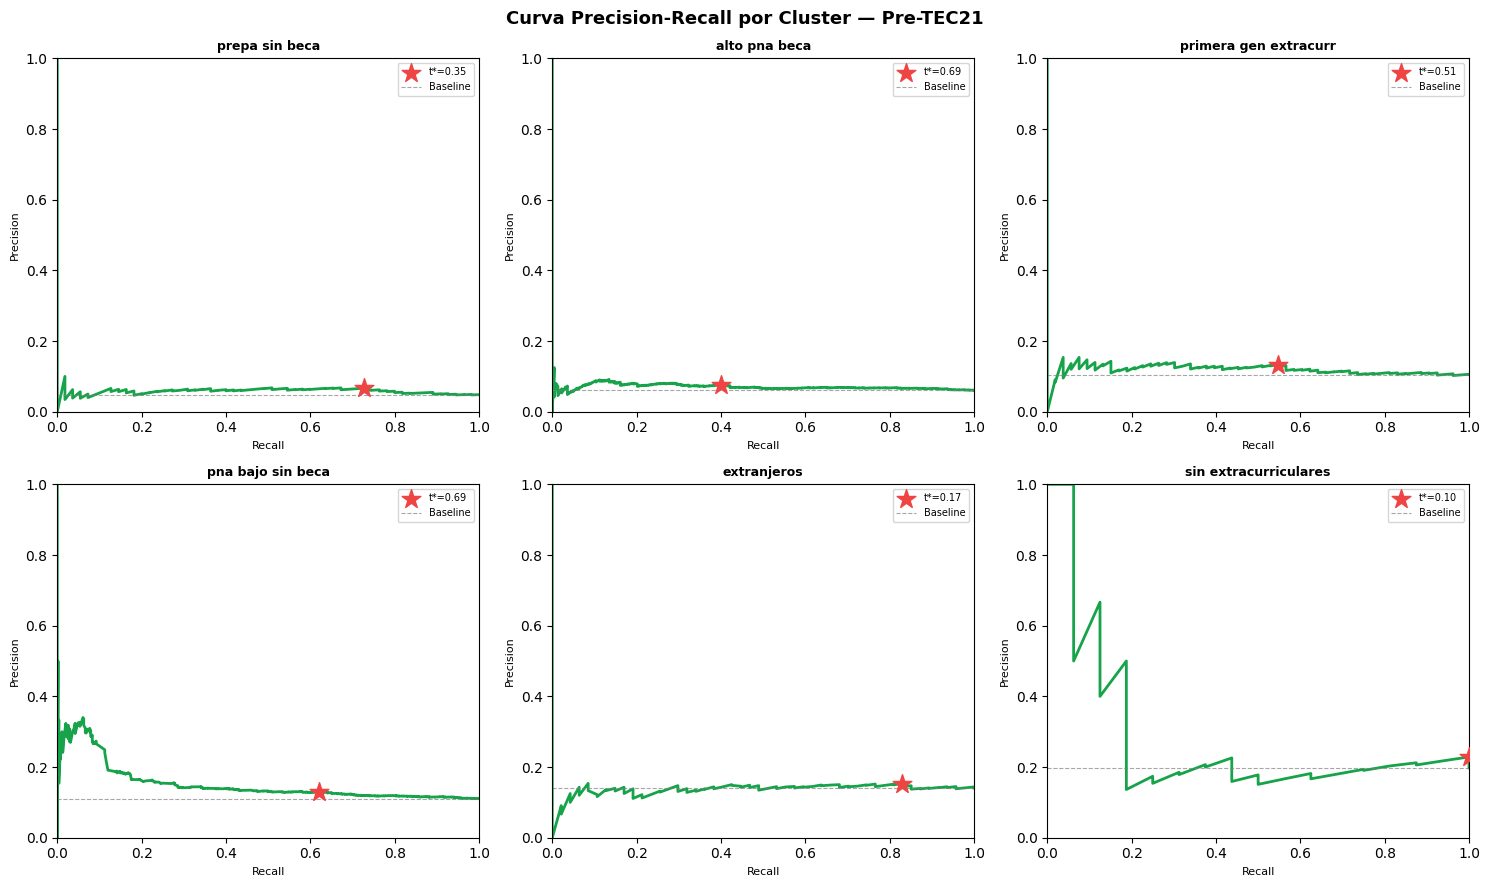

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Curva Precision-Recall por Cluster — Pre-TEC21', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_pre):
    r = models_pre[cl]
    prec_curve, rec_curve, thresh_curve = precision_recall_curve(r['y_te'], r['y_proba'])
    ax.plot(rec_curve, prec_curve, color='#16a34a', lw=2)

    # Marcar umbral óptimo
    t_opt = r['threshold']
    y_pred_opt = (r['y_proba'] >= t_opt).astype(int)
    p_opt = precision_score(r['y_te'], y_pred_opt, zero_division=0)
    rec_opt = recall_score(r['y_te'], y_pred_opt, zero_division=0)
    ax.scatter([rec_opt], [p_opt], marker='*', s=200, color='#ef4444',
               zorder=5, label=f't*={t_opt:.2f}')

    # Línea de referencia (baseline = tasa de deserción)
    baseline = r['y_te'].mean()
    ax.axhline(baseline, color='gray', linestyle='--', lw=0.8, alpha=0.7, label='Baseline')

    title = cl.split('_',1)[1].replace('_',' ')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=8)
    ax.set_ylabel('Precision', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

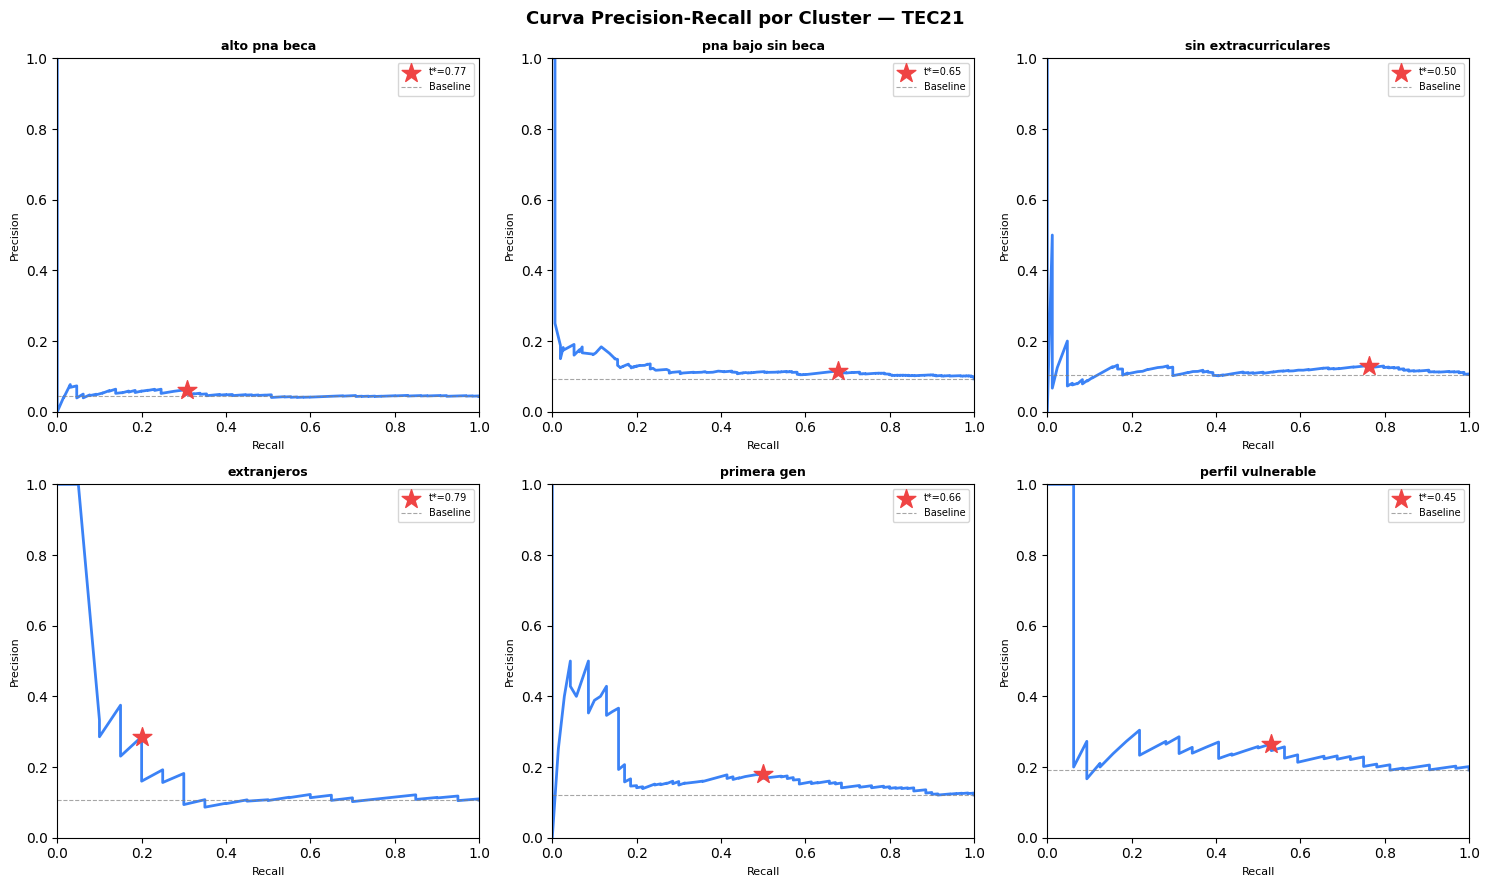

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Curva Precision-Recall por Cluster — TEC21', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_tec):
    r = models_tec[cl]
    prec_curve, rec_curve, thresh_curve = precision_recall_curve(r['y_te'], r['y_proba'])
    ax.plot(rec_curve, prec_curve, color='#3b82f6', lw=2)

    t_opt = r['threshold']
    y_pred_opt = (r['y_proba'] >= t_opt).astype(int)
    p_opt = precision_score(r['y_te'], y_pred_opt, zero_division=0)
    rec_opt = recall_score(r['y_te'], y_pred_opt, zero_division=0)
    ax.scatter([rec_opt], [p_opt], marker='*', s=200, color='#ef4444',
               zorder=5, label=f't*={t_opt:.2f}')

    baseline = r['y_te'].mean()
    ax.axhline(baseline, color='gray', linestyle='--', lw=0.8, alpha=0.7, label='Baseline')

    title = cl.split('_',1)[1].replace('_',' ')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=8)
    ax.set_ylabel('Precision', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## 9. Comparación de Métricas — Umbral Defecto vs Óptimo

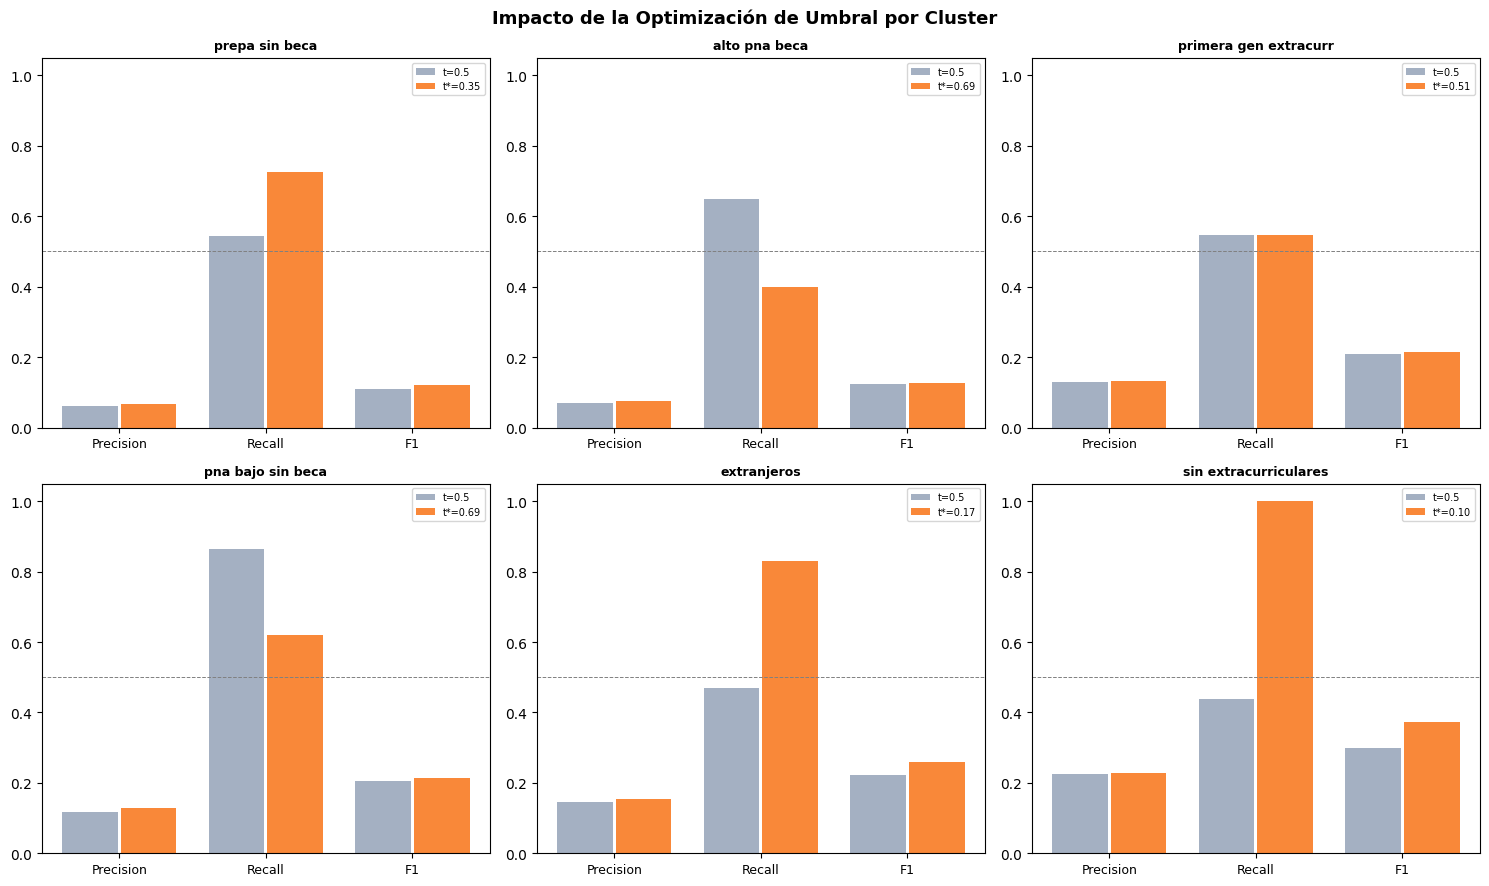

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Impacto de la Optimización de Umbral por Cluster', fontsize=13, fontweight='bold')

all_clusters = list(models_pre.items()) + list(models_tec.items())
for ax, (cl, res) in zip(axes.flat, all_clusters[:6]):
    m    = res['metrics']
    cats = ['Precision', 'Recall', 'F1']
    def_vals = [m['prec_default'], m['rec_default'], m['f1_default']]
    opt_vals = [m['precision'],    m['recall'],       m['f1']]

    x = np.arange(3)
    ax.bar(x - 0.2, def_vals, width=0.38, color='#94a3b8', alpha=0.85, label='t=0.5')
    ax.bar(x + 0.2, opt_vals, width=0.38, color='#f97316', alpha=0.85, label=f"t*={m['threshold']:.2f}")
    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.axhline(0.5, color='gray', linestyle='--', lw=0.7)

plt.tight_layout()
plt.show()

---
## 10. Matrices de Confusión con Umbral Óptimo

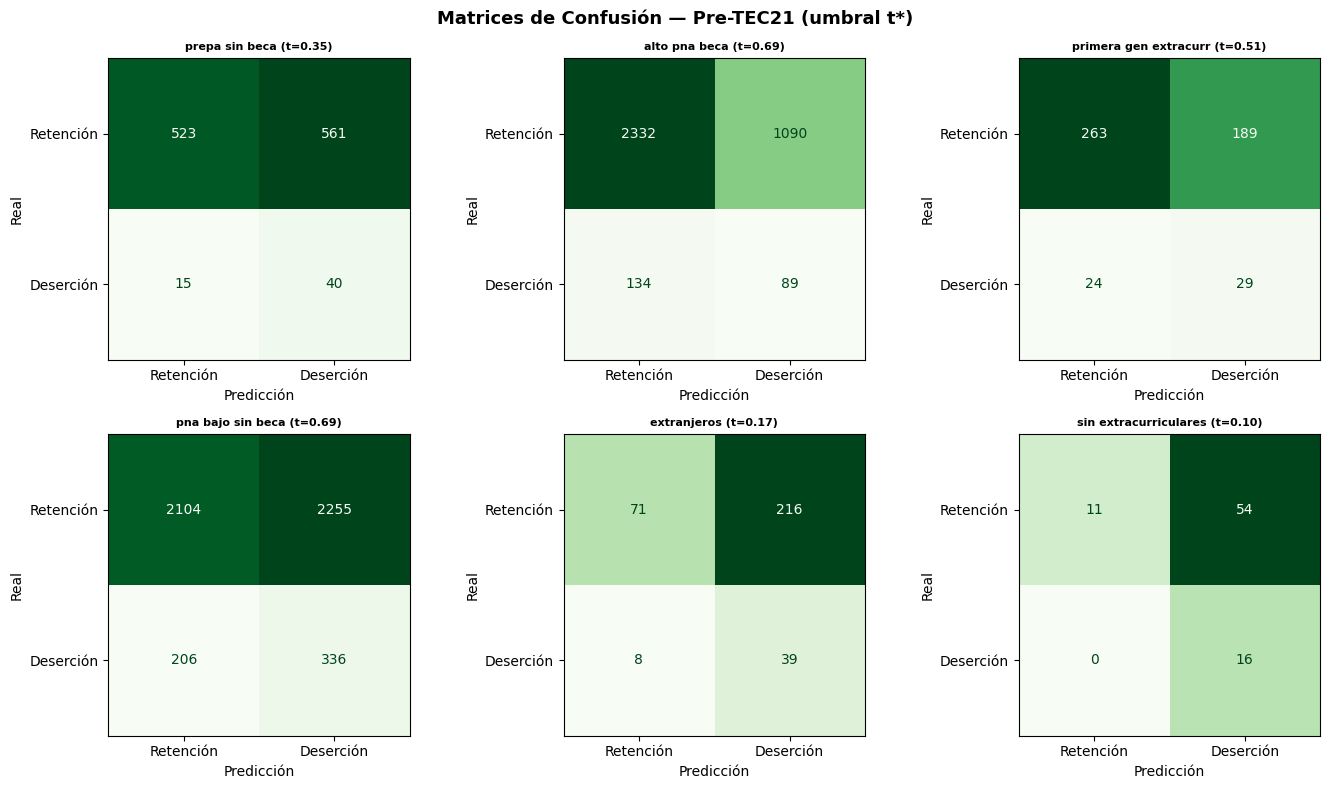

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Matrices de Confusión — Pre-TEC21 (umbral t*)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_pre):
    r = models_pre[cl]
    y_pred = (r['y_proba'] >= r['threshold']).astype(int)
    cm = confusion_matrix(r['y_te'], y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retención','Deserción'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    t = r['threshold']
    ax.set_title(f"{cl.split('_',1)[1].replace('_',' ')} (t={t:.2f})",
                 fontsize=8, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

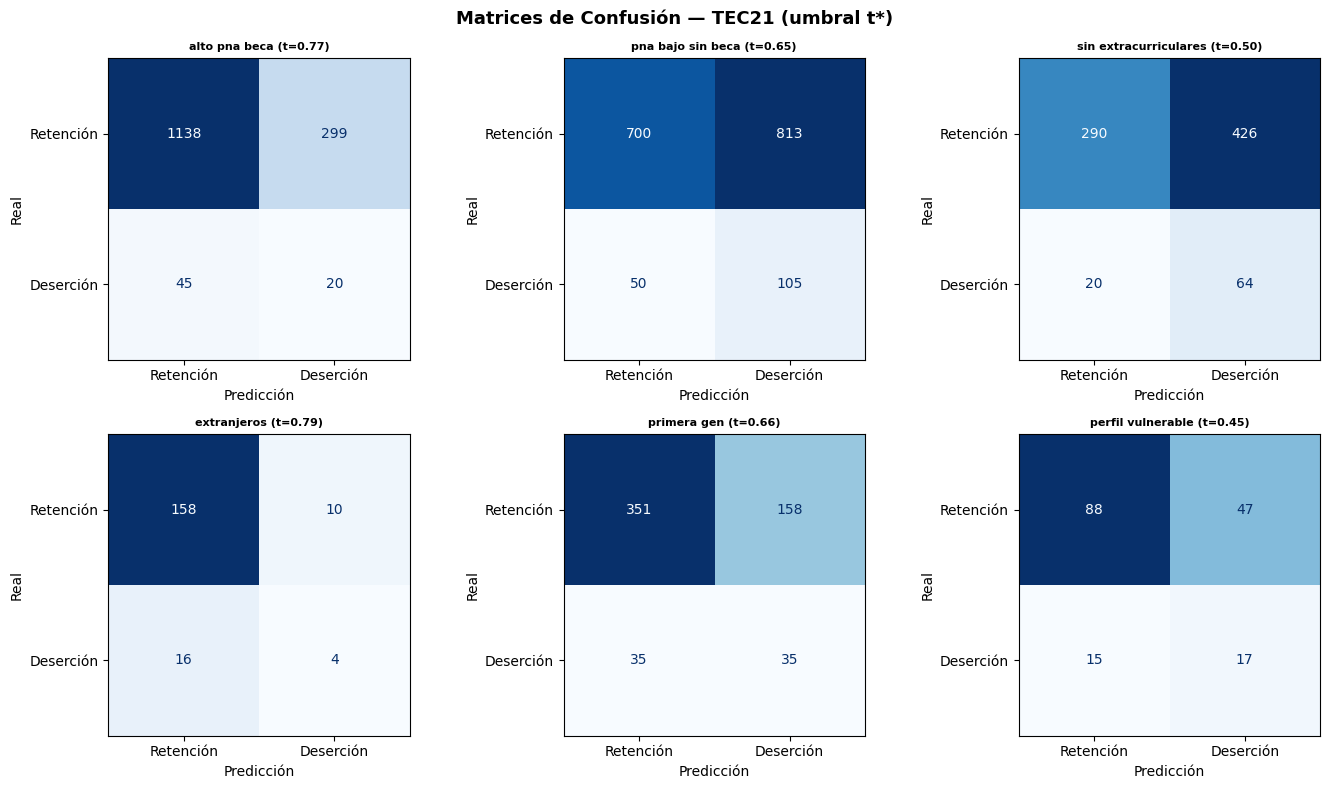

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Matrices de Confusión — TEC21 (umbral t*)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_tec):
    r = models_tec[cl]
    y_pred = (r['y_proba'] >= r['threshold']).astype(int)
    cm = confusion_matrix(r['y_te'], y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retención','Deserción'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    t = r['threshold']
    ax.set_title(f"{cl.split('_',1)[1].replace('_',' ')} (t={t:.2f})",
                 fontsize=8, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

---
## 11. SHAP Values — Importancia de Variables
`mean(|SHAP|)` mide cuánto contribuye cada variable en promedio a mover la predicción,
sin importar la dirección. Cuanto más alto, más decisiva es esa variable dentro del cluster.

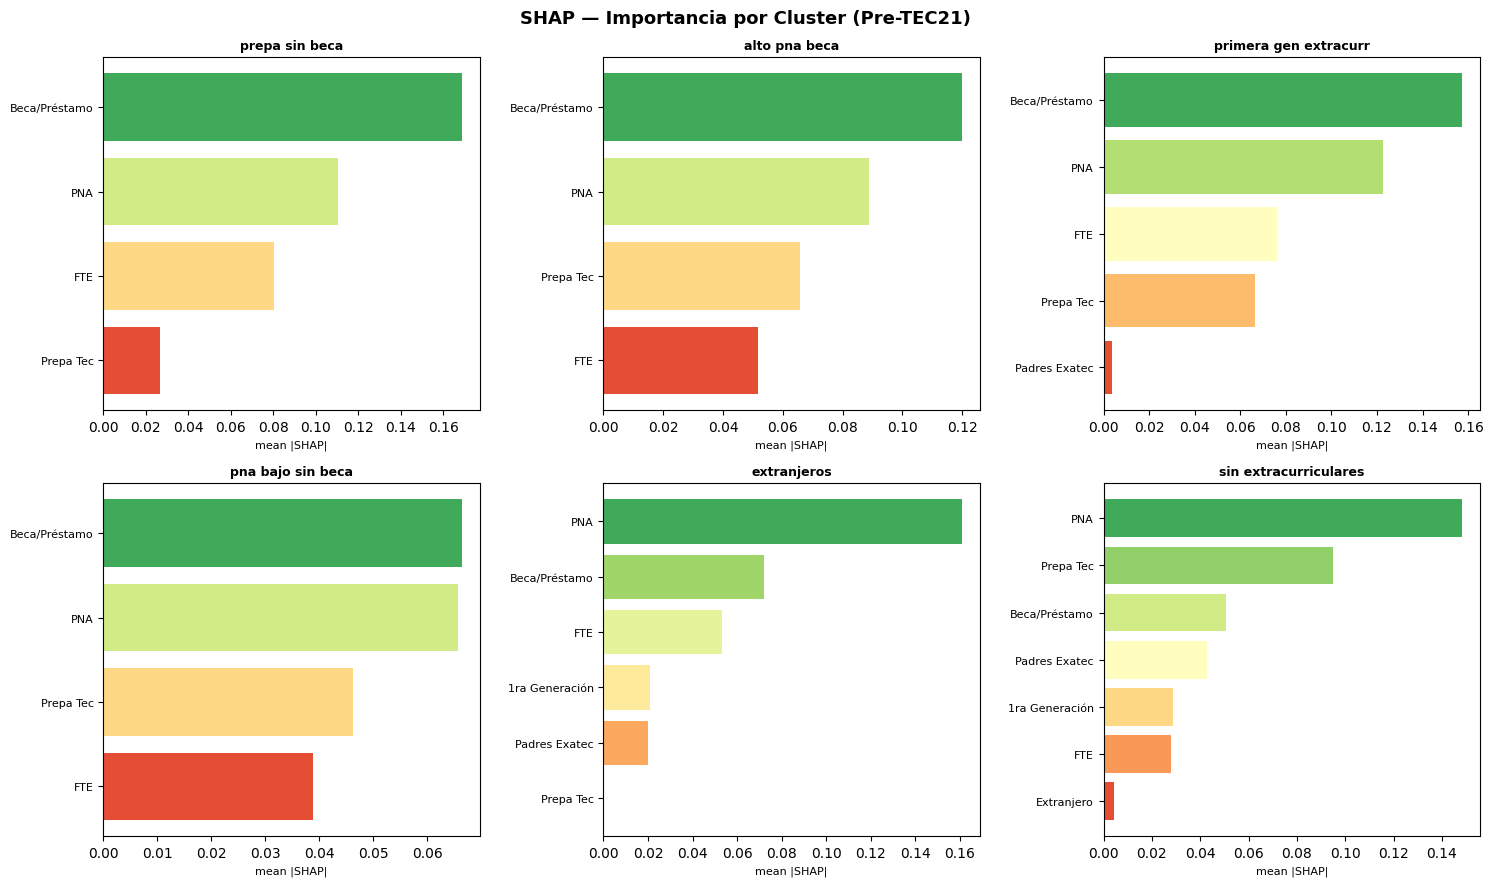

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('SHAP — Importancia por Cluster (Pre-TEC21)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_pre):
    r  = models_pre[cl]
    ms = np.abs(r['shap']).mean(axis=0)
    fn = [FEAT_LABELS.get(f, f) for f in r['feats']]
    order = np.argsort(ms)[::-1]
    vals, labs = ms[order], [fn[j] for j in order]
    colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(vals)))
    ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labs, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('mean |SHAP|', fontsize=8)

plt.tight_layout()
plt.show()

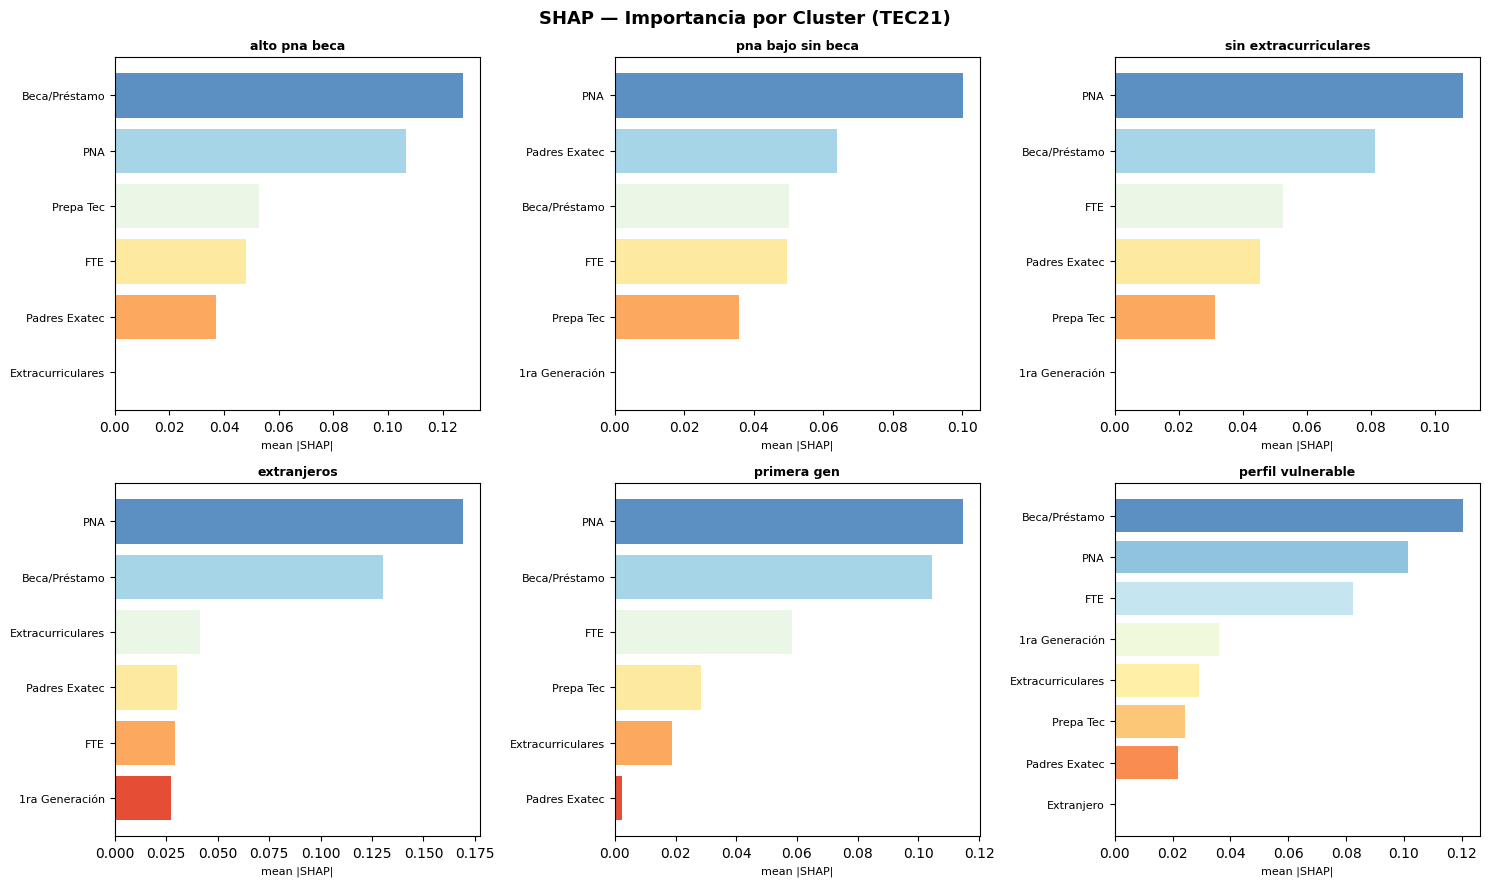

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('SHAP — Importancia por Cluster (TEC21)', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_tec):
    r  = models_tec[cl]
    ms = np.abs(r['shap']).mean(axis=0)
    fn = [FEAT_LABELS.get(f, f) for f in r['feats']]
    order = np.argsort(ms)[::-1]
    vals, labs = ms[order], [fn[j] for j in order]
    colors = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, len(vals)))
    ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labs, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(cl.split('_',1)[1].replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('mean |SHAP|', fontsize=8)

plt.tight_layout()
plt.show()

---
## 12. SHAP Beeswarm — Dirección del Efecto
Cada punto es un estudiante del test set.
**Rojo** = valor alto de la variable | **Azul** = valor bajo.
**Derecha (positivo)** = empuja hacia deserción | **Izquierda (negativo)** = empuja hacia retención.

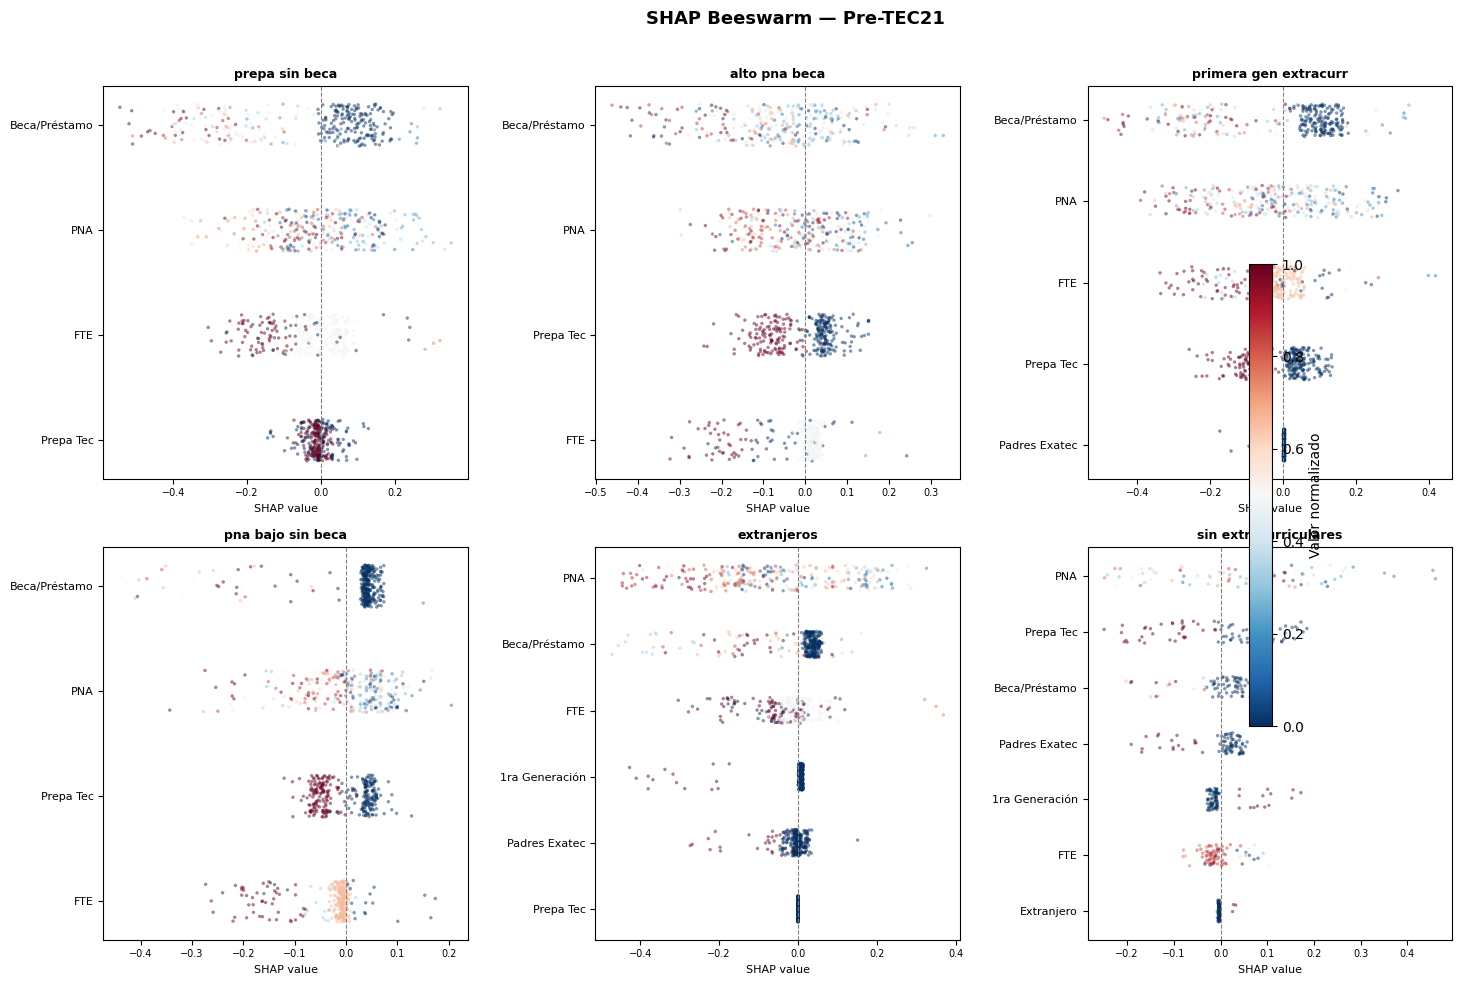

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SHAP Beeswarm — Pre-TEC21', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_pre):
    r  = models_pre[cl]
    fn = [FEAT_LABELS.get(f, f) for f in r['feats']]
    custom_beeswarm(ax, r['shap'], r['X_te_shap'], fn, cl.split('_',1)[1].replace('_',' '))

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(0,1))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Valor normalizado', shrink=0.6, pad=0.02)
plt.tight_layout(rect=[0,0,0.92,0.97])
plt.show()

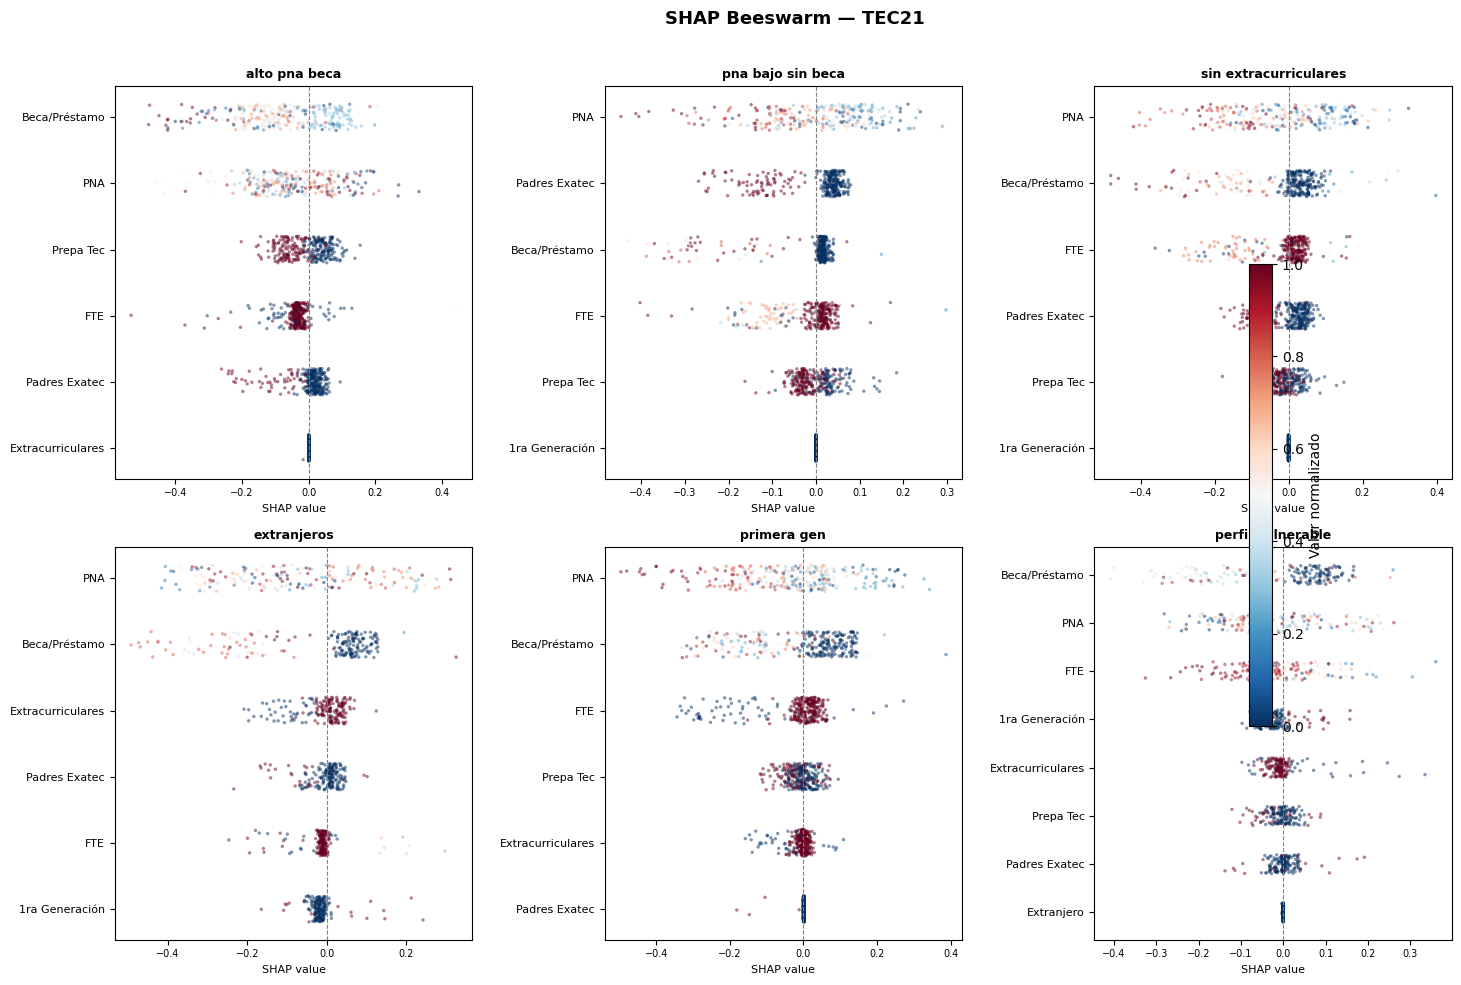

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SHAP Beeswarm — TEC21', fontsize=13, fontweight='bold')

for ax, cl in zip(axes.flat, clusters_tec):
    r  = models_tec[cl]
    fn = [FEAT_LABELS.get(f, f) for f in r['feats']]
    custom_beeswarm(ax, r['shap'], r['X_te_shap'], fn, cl.split('_',1)[1].replace('_',' '))

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(0,1))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Valor normalizado', shrink=0.6, pad=0.02)
plt.tight_layout(rect=[0,0,0.92,0.97])
plt.show()

---
## 13. Resumen Consolidado

In [15]:
def print_summary(mdf, label):
    print("=" * 100)
    print(f"{label} — XGBoost con SMOTE + Umbral Óptimo")
    print("=" * 100)
    print(f"{'Cluster':<38} {'n':>7} {'Drop%':>6} | "
          f"{'P(0.5)':>7} {'R(0.5)':>7} {'F1(0.5)':>7} | "
          f"{'t*':>5} {'P(t*)':>7} {'R(t*)':>7} {'F1(t*)':>7} {'AUC':>7}")
    print("-" * 100)
    for _, row in mdf.reset_index().iterrows():
        print(f"{row.cluster:<38} {row.n:>7,} {row.dropout_rate:>5.1%} | "
              f"{row.prec_default:>7.3f} {row.rec_default:>7.3f} {row.f1_default:>7.3f} | "
              f"{row.threshold:>5.2f} {row.precision:>7.3f} {row.recall:>7.3f} {row.f1:>7.3f} {row.auc_roc:>7.3f}")
    avg_f1 = mdf['f1'].mean()
    avg_auc = mdf['auc_roc'].mean()
    print(f"{'PROMEDIO':<38} {'':>7} {'':>6} | {'':>7} {'':>7} {'':>7} | {'':>5} {'':>7} {'':>7} {avg_f1:>7.3f} {avg_auc:>7.3f}")

print_summary(metrics_pre, 'Pre-TEC21')
print()
print_summary(metrics_tec, 'TEC21')

Pre-TEC21 — XGBoost con SMOTE + Umbral Óptimo
Cluster                                      n  Drop% |  P(0.5)  R(0.5) F1(0.5) |    t*   P(t*)   R(t*)  F1(t*)     AUC
----------------------------------------------------------------------------------------------------
C0_prepa_sin_beca                        5,695  4.8% |   0.061   0.545   0.110 |  0.35   0.067   0.727   0.122   0.582
C1_alto_pna_beca                        18,221  6.1% |   0.069   0.650   0.124 |  0.69   0.075   0.399   0.127   0.551
C2_primera_gen_extracurr                 2,521 10.6% |   0.129   0.547   0.209 |  0.51   0.133   0.547   0.214   0.546
C3_pna_bajo_sin_beca                    24,505 11.1% |   0.116   0.863   0.204 |  0.69   0.130   0.620   0.214   0.567
C4_extranjeros                           1,667 14.2% |   0.147   0.468   0.223 |  0.17   0.153   0.830   0.258   0.506
C5_sin_extracurriculares                   401 20.2% |   0.226   0.438   0.298 |  0.10   0.229   1.000   0.372   0.491
PROMEDIO           

In [16]:
# Variable top SHAP por cluster
print()
print("=" * 68)
print("Variable MÁS INFLUYENTE (SHAP) por Cluster — XGBoost")
print("=" * 68)

for label, clusters, models in [("Pre-TEC21", clusters_pre, models_pre),
                                  ("TEC21",     clusters_tec, models_tec)]:
    print(f"\n{label}:")
    for cl in clusters:
        r  = models[cl]
        ms = np.abs(r['shap']).mean(axis=0)
        ti = np.argmax(ms)
        tf = FEAT_LABELS.get(r['feats'][ti], r['feats'][ti])
        print(f"  {cl.split('_',1)[1].replace('_',' '):<35} → {tf:<22} (|SHAP|={ms[ti]:.4f})")


Variable MÁS INFLUYENTE (SHAP) por Cluster — XGBoost

Pre-TEC21:
  prepa sin beca                      → Beca/Préstamo          (|SHAP|=0.1688)
  alto pna beca                       → Beca/Préstamo          (|SHAP|=0.1199)
  primera gen extracurr               → Beca/Préstamo          (|SHAP|=0.1574)
  pna bajo sin beca                   → Beca/Préstamo          (|SHAP|=0.0664)
  extranjeros                         → PNA                    (|SHAP|=0.1609)
  sin extracurriculares               → PNA                    (|SHAP|=0.1484)

TEC21:
  alto pna beca                       → Beca/Préstamo          (|SHAP|=0.1274)
  pna bajo sin beca                   → PNA                    (|SHAP|=0.1001)
  sin extracurriculares               → PNA                    (|SHAP|=0.1087)
  extranjeros                         → PNA                    (|SHAP|=0.1691)
  primera gen                         → PNA                    (|SHAP|=0.1146)
  perfil vulnerable                   → Beca/Préstamo    

---
## 14. Interpretación de Resultados

### Sobre las métricas

**AUC-ROC** es la métrica más confiable aquí. Un AUC > 0.65 indica que el modelo
distingue desertores de no-desertores mejor que el azar, incluso si F1 es moderado.
AUC = 0.5 es azar puro; AUC = 1.0 es perfecto.

**F1 con umbral óptimo** vs F1 con umbral 0.5: la diferencia entre ambas columnas
revela cuánto gana el modelo con la optimización de umbral. Una ganancia grande (>0.05)
indica que el modelo tenía buen poder discriminativo pero el umbral por defecto lo
desperdiciaba.

**Recall alto + Precision baja**: el modelo detecta muchos desertores pero genera
falsas alarmas. Útil si el costo de no detectar un desertor es alto (intervención temprana).

**Precision alta + Recall bajo**: el modelo es conservador, solo alerta cuando está
muy seguro. Útil si los recursos de intervención son limitados.

---

### ¿Por qué el F1 sigue siendo moderado?

El techo de rendimiento está determinado por las **variables disponibles**, no por el algoritmo.
Las 8 variables de perfil de entrada son características de admisión estáticas.
El clustering ya agrupó a estudiantes similares en estas dimensiones, lo que significa
que dentro de cada cluster los estudiantes son parecidos entre sí: el modelo tiene
menos señal para separar desertores de no-desertores.

**Esto no es un fallo del modelo**: es un hallazgo científico. Indica que el perfil
de entrada por sí solo tiene poder predictivo limitado dentro de cada subgrupo homogéneo.
Las variables que mejor diferenciarían serían dinámicas: calificaciones del primer semestre,
carga crediticia, cambios en FTE, número de materias reprobadas.

---

### Comparación XGBoost vs Random Forest

XGBoost mejora principalmente el **AUC-ROC** (ranking de probabilidades) y el
**recall con umbral óptimo**, gracias a que el boosting concentra esfuerzo en los
ejemplos difíciles (estudiantes fronterizos entre desertar y quedarse). La ganancia
en F1 es más modesta porque ambos modelos operan con las mismas 8 variables.

---

### Implicación para la pregunta de investigación

Si los SHAP values de las mismas variables tienen **magnitudes similares** en Pre-TEC21
y TEC21 para clusters equivalentes, hay evidencia de **invarianza pedagógica**: las
variables que predicen deserción no cambiaron entre modelos educativos.
Si las magnitudes cambian sustancialmente, sugiere que el cambio de modelo educativo
**reconfiguró** qué factores predicen el abandono.